<a href="https://colab.research.google.com/github/min0left-hub/mobis_ai_education_2026/blob/main/DL_07_A_GAN_BRKT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GAN (Generative Adversarial Networks)

- GAN : https://proceedings.neurips.cc/paper_files/paper/2014/file/5ca3e9b122f61f8f06494c97b1afccf3-Paper.pdf

## 1. Load dataset

In [1]:
!gdown --folder https://drive.google.com/drive/folders/12_pMH77NyqSnp8NY0EFzZn1dODgrx_p8?usp=drive_link
!unzip dataset/data_2000.zip -d ./data2000

Retrieving folder contents
Processing file 1-sRJSDLohsZlEXFJizzz8ovYZDqJfI-V data_100_test.zip
Processing file 1T6zw4ggFfFlPQChqWia-VLKct1DTSLK6 data_500.zip
Processing file 1kHHoZPyk0_lCJYwqqaxd0hmBAdAxqEQY data_1000.zip
Processing file 12M-FQcVzzumCnhmFrzPkzeBoBZQtBSbj data_2000.zip
Processing file 1pNYu7bAEp8Lw08-VXMmHAgmEnJNhuhAF data_3000.zip
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1-sRJSDLohsZlEXFJizzz8ovYZDqJfI-V
To: /content/dataset/data_100_test.zip
100% 113k/113k [00:00<00:00, 40.1MB/s]
Downloading...
From: https://drive.google.com/uc?id=1T6zw4ggFfFlPQChqWia-VLKct1DTSLK6
To: /content/dataset/data_500.zip
100% 567k/567k [00:00<00:00, 56.4MB/s]
Downloading...
From: https://drive.google.com/uc?id=1kHHoZPyk0_lCJYwqqaxd0hmBAdAxqEQY
To: /content/dataset/data_1000.zip
100% 1.20M/1.20M [00:00<00:00, 156MB/s]
Downloading...
From: https://drive.google.com/uc?id=12M-FQcVz

## 2. Import python libraries and define util functions

In [2]:
import numpy as np
import pandas as pd
import cv2 as cv
import matplotlib.pyplot as plt
import os
import random

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader,TensorDataset
from torch.utils.data.dataset import random_split
from torchvision.utils import save_image
from torchsummary import summary

import scipy.io
from sklearn.model_selection import train_test_split

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# function to set seed
def set_seed(seed=42):
    # fix random seed
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    # CuDNN setup
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# function to read and display images
def img_read_plot(src,file):
    img = cv.imread(src+file,cv.COLOR_BGR2GRAY)  # convert the image to grayscale
    plt.imshow(img, cmap='gray')
    plt.xticks([])  # x axis
    plt.yticks([])  # y axis
    plt.show()  # display the image
    return img

# function to read images
def img_read(src,file):
    img = cv.imread(src+file,cv.COLOR_BGR2GRAY)  # convert the image to grayscale
    return img

# function to plot a line graph for loss history after model training
def plot_loss(g_loss, d_loss, title=None):

    plt.plot(g_loss)
    plt.plot(d_loss)
    if title is not None:
        plt.title(title)
    plt.ylabel('Loss')
    plt.xlabel('Epochs')
    plt.legend(['Generator Loss', 'Discriminator Loss'], loc=0)
    # plt.show()

In [3]:
set_seed(0)

## 3. Check dataset

In [4]:
path = './data2000/23.119.jpg'
from PIL import Image
img = Image.open(path)
img.show()
img_array = np.array(img)
print(img_array.shape)

(56, 56)


## 4. Convert images into trainable data

In [5]:
# image size = 56 x 56, 2000 images

# specify the below path to the unzipped data (ensure it ends with '/')
# you can change the file path if needed
src = './data2000/'

# loop through the files, read each image, and normalize it (-1 to 1)
def get_data():
    files = os.listdir(src)  # get the list of files in the source directory
    X = []  # initialize empty lists for storing images

    for file in files:
        X.append((img_read(src,file)-127.5)/127.5)  # normalize the data between -1 and 1

    # split the data into 80% training set and 20% test set (test set can be considered as validation)
    X_train, X_test = train_test_split(X, test_size=0.2, random_state=1,shuffle=True)

    # expand dimension to (batch_size, 1, height, width) in PyTorch
    X_train = np.expand_dims(X_train, axis=1)  # axis=1 for channel in PyTorch
    X_test = np.expand_dims(X_test, axis=1)  # same for test set

    return X_train, X_test

X_train, X_test = get_data()  # load data set (no y label needed as we only need images) / unsupervised learning

print("X_train.shape = {}".format(X_train.shape))
print("X_test.shape = {}".format(X_test.shape))

X_train.shape = (1600, 1, 56, 56)
X_test.shape = (400, 1, 56, 56)


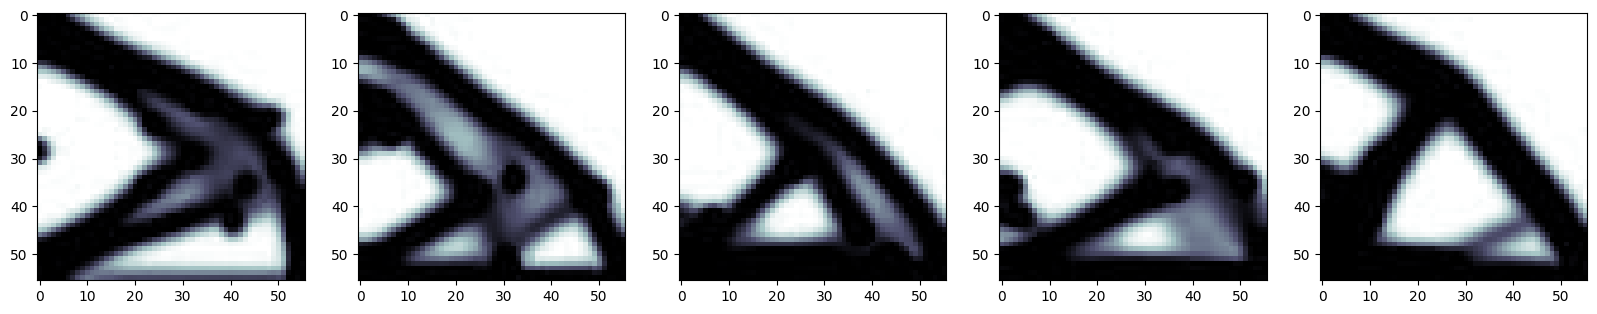

In [6]:
# display images
fig = plt.figure(figsize=(20,10))
nplot = 5

for i in range(1,nplot+1):
    ax = fig.add_subplot(1,nplot,i)
    ax.imshow(X_train[i, 0, :, :],cmap = plt.cm.bone)
plt.show()

## 5. Set to model architecture

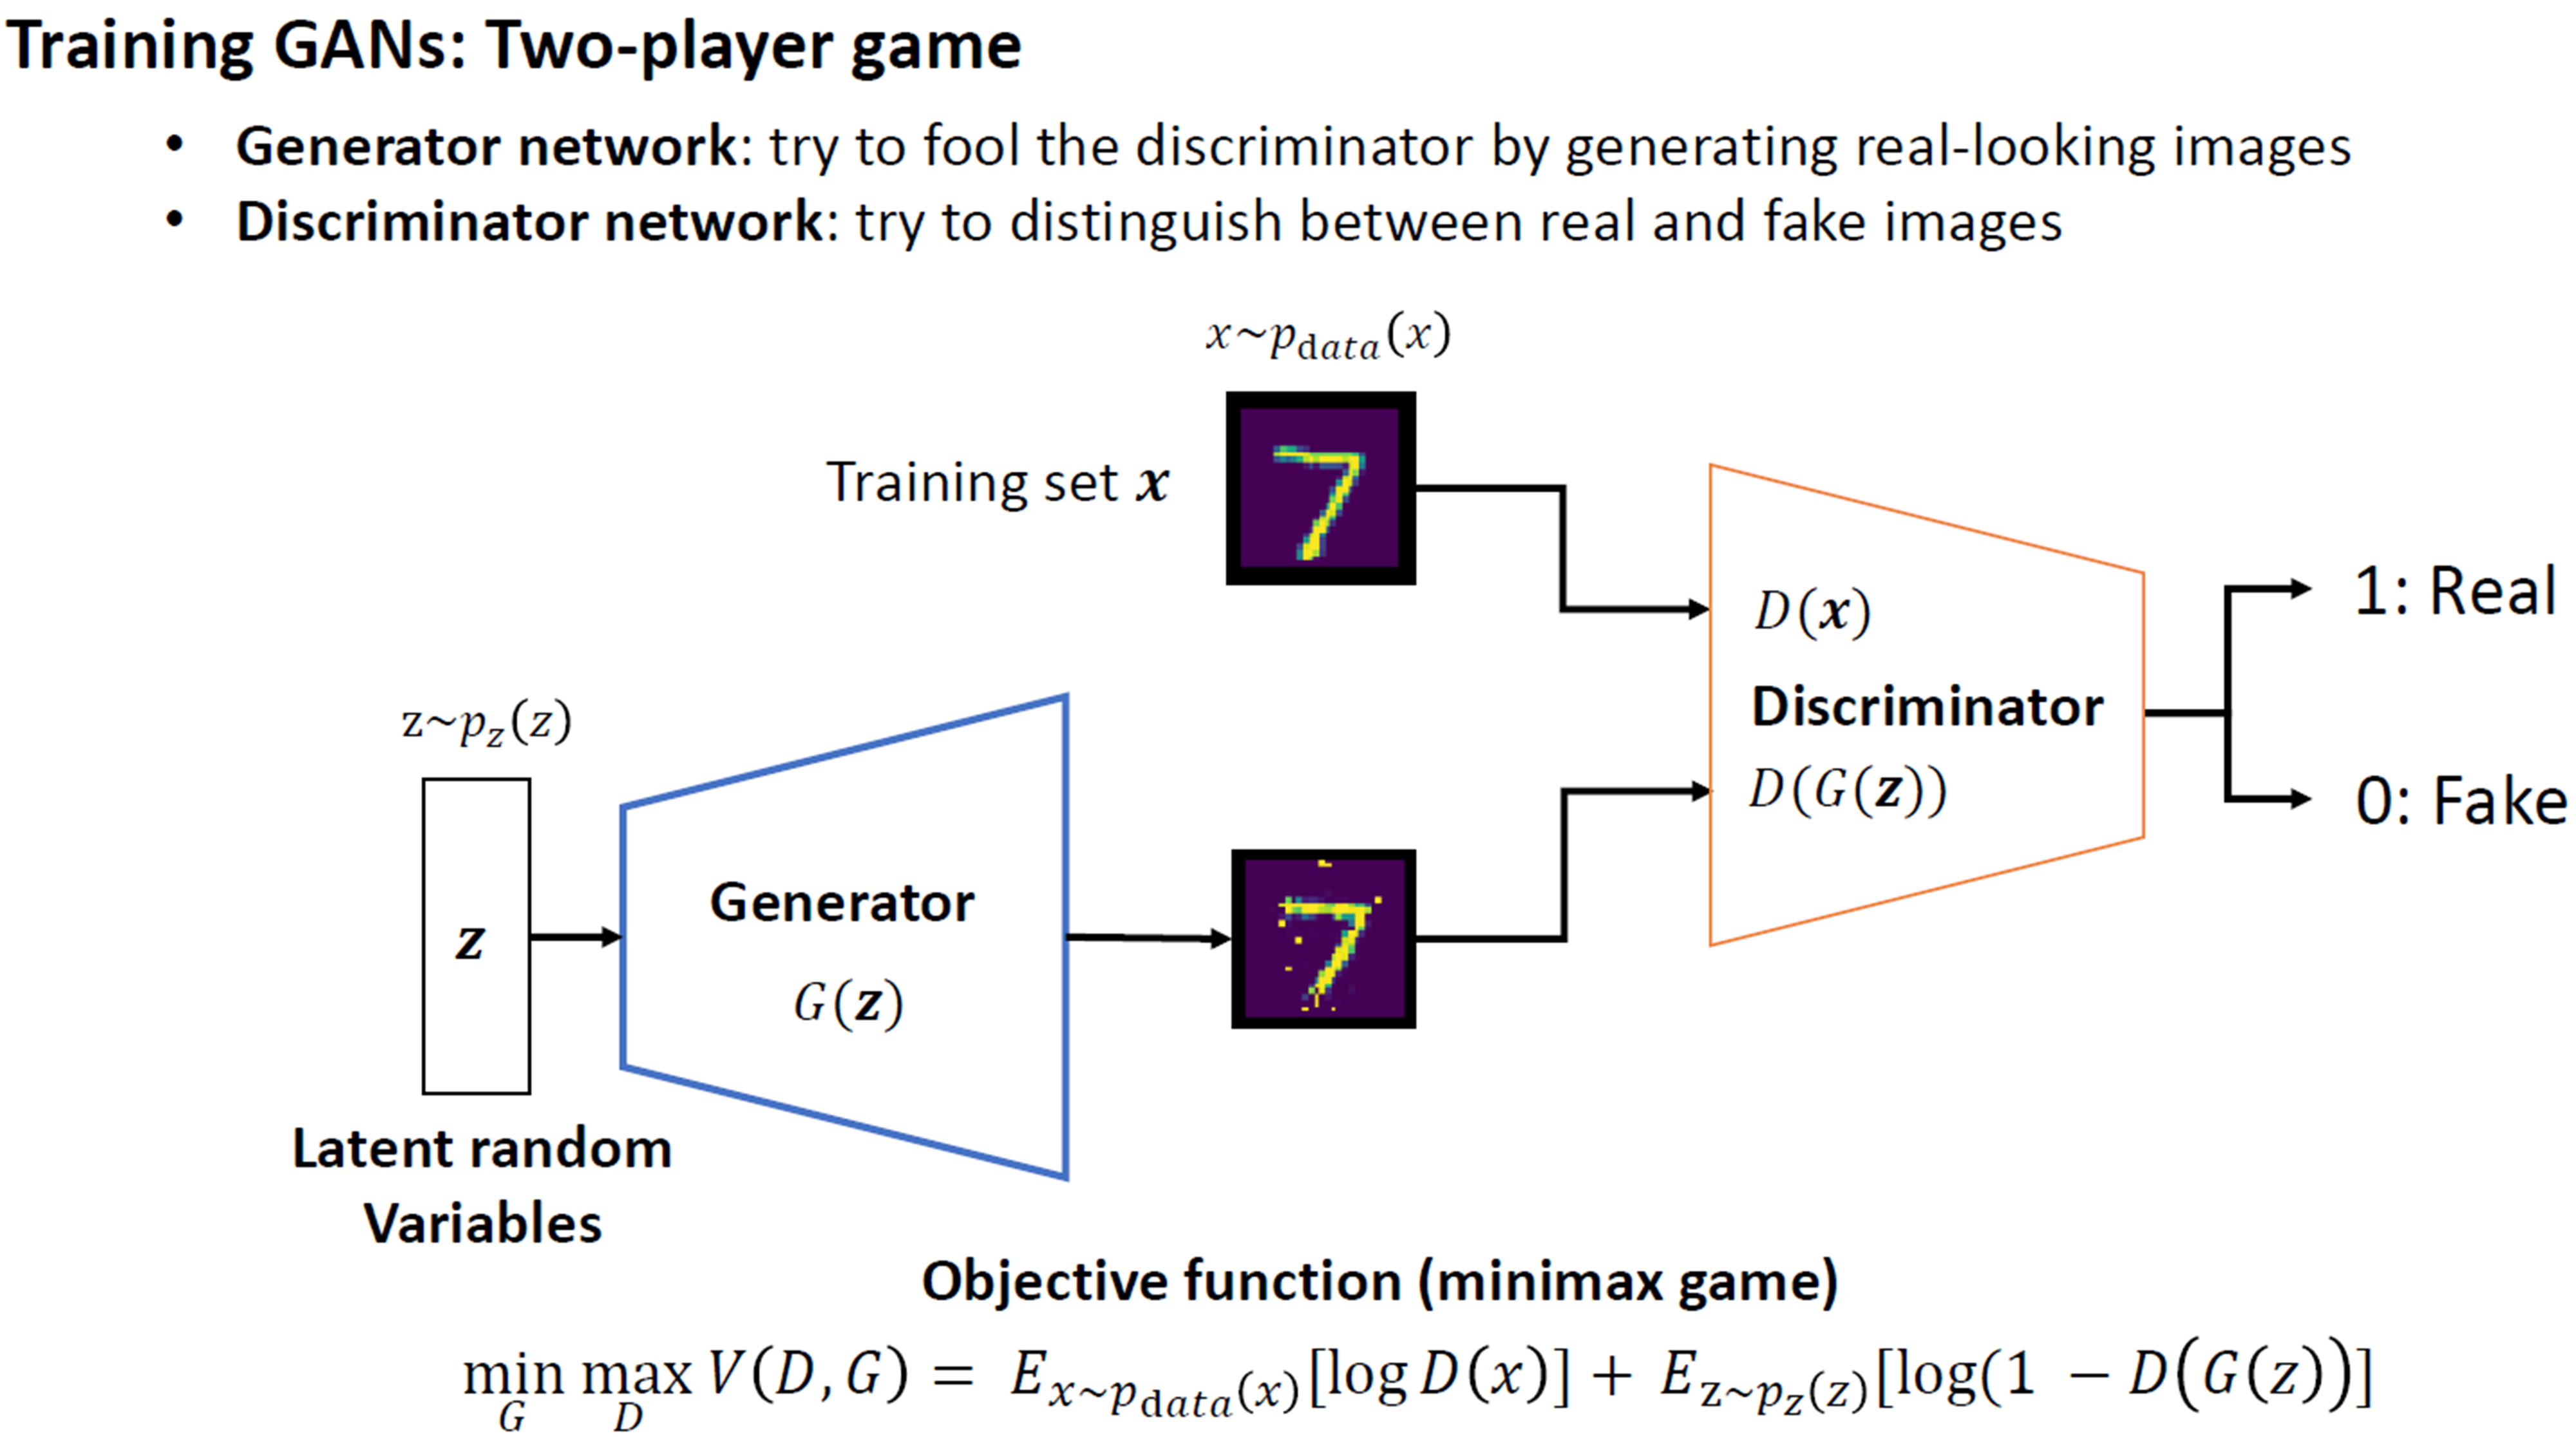

In [8]:
def reset_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

reset_seed(42)

Device: cuda


In [36]:
config = {
    "name": "gan_weaker_discriminator",

    "img_size": 56 * 56,
    "img_shape": (1, 56, 56),
    "noise_size": 100,

    "g_hidden_dims": [128, 512, 1024],
    "d_hidden_dims": [512, 128, 64],

    "g_dropout": 0.1,
    "d_dropout": 0.3,
    "leaky_relu_slope": 0.2,

    "epochs": 500,
    "batch_size": 32,

    "g_lr": 2e-4,
    "d_lr": 1e-4,

    "betas": (0.5, 0.999),

    "g_weight_decay": 0.0,
    "d_weight_decay": 1e-5,

    "d_steps": 1,
    "g_steps": 2,

    "num_fixed_samples": 10,
    "sample_interval": 50,

    "seed": 42
}

In [37]:
reset_seed(config["seed"])

train_images = torch.tensor(X_train, dtype=torch.float32)
test_images = torch.tensor(X_test, dtype=torch.float32)

train_dataset = TensorDataset(train_images)
test_dataset = TensorDataset(test_images)

train_loader = DataLoader(
    train_dataset,
    batch_size=config["batch_size"],
    shuffle=True,
    drop_last=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=config["batch_size"],
    shuffle=False,
    drop_last=False
)

print("train_images:", train_images.shape)
print("test_images :", test_images.shape)
print("Train size  :", len(train_dataset))
print("Test size   :", len(test_dataset))
print("Batch size  :", config["batch_size"])
print("Train batches:", len(train_loader))

train_images: torch.Size([1600, 1, 56, 56])
test_images : torch.Size([400, 1, 56, 56])
Train size  : 1600
Test size   : 400
Batch size  : 32
Train batches: 50


In [38]:
class Generator(nn.Module):
    def __init__(self, noise_size, img_size, hidden_dims, dropout_rate=0.1):
        super(Generator, self).__init__()

        layers = []
        in_dim = noise_size

        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(in_dim, hidden_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_rate))
            in_dim = hidden_dim

        layers.append(nn.Linear(in_dim, img_size))
        layers.append(nn.Tanh())

        self.generator = nn.Sequential(*layers)

    def forward(self, z):
        return self.generator(z)

In [39]:
class Discriminator(nn.Module):
    def __init__(self, img_size, hidden_dims, dropout_rate=0.1, leaky_relu_slope=0.2):
        super(Discriminator, self).__init__()

        layers = []
        in_dim = img_size

        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(in_dim, hidden_dim))
            layers.append(nn.LeakyReLU(leaky_relu_slope))
            layers.append(nn.Dropout(dropout_rate))
            in_dim = hidden_dim

        layers.append(nn.Linear(in_dim, 1))
        layers.append(nn.Sigmoid())

        self.discriminator = nn.Sequential(*layers)

    def forward(self, x):
        return self.discriminator(x)

In [40]:
reset_seed(config["seed"])

generator = Generator(
    noise_size=config["noise_size"],
    img_size=config["img_size"],
    hidden_dims=config["g_hidden_dims"],
    dropout_rate=config["g_dropout"]
).to(device)

discriminator = Discriminator(
    img_size=config["img_size"],
    hidden_dims=config["d_hidden_dims"],
    dropout_rate=config["d_dropout"],
    leaky_relu_slope=config["leaky_relu_slope"]
).to(device)

criterion = nn.BCELoss()

g_optimizer = optim.Adam(
    generator.parameters(),
    lr=config["g_lr"],
    betas=config["betas"],
    weight_decay=config["g_weight_decay"]
)

d_optimizer = optim.Adam(
    discriminator.parameters(),
    lr=config["d_lr"],
    betas=config["betas"],
    weight_decay=config["d_weight_decay"]
)

print(generator)
print(discriminator)

summary(generator, (config["noise_size"],))
summary(discriminator, (config["img_size"],))

Generator(
  (generator): Sequential(
    (0): Linear(in_features=100, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=128, out_features=512, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.1, inplace=False)
    (6): Linear(in_features=512, out_features=1024, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.1, inplace=False)
    (9): Linear(in_features=1024, out_features=3136, bias=True)
    (10): Tanh()
  )
)
Discriminator(
  (discriminator): Sequential(
    (0): Linear(in_features=3136, out_features=512, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=512, out_features=128, bias=True)
    (4): LeakyReLU(negative_slope=0.2)
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=128, out_features=64, bias=True)
    (7): LeakyReLU(negative_slope=0.2)
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=64, out_features=1, bias=True

In [41]:
sample_dir = f"./GAN_samples_{config['name']}"
os.makedirs(sample_dir, exist_ok=True)

fixed_noise = torch.randn(
    config["num_fixed_samples"],
    config["noise_size"]
).to(device)

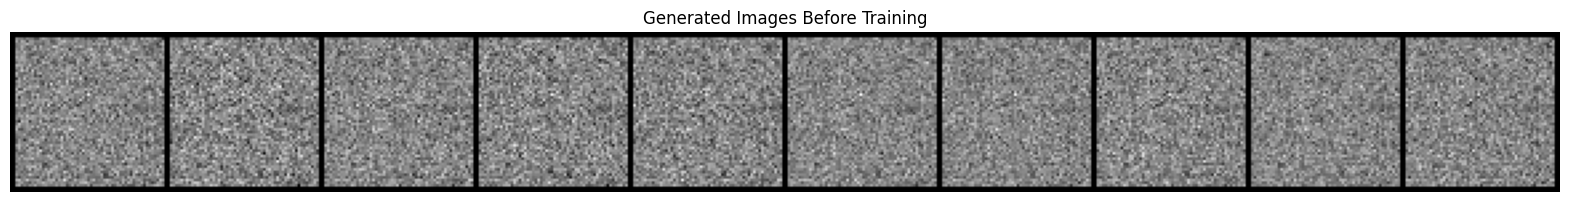

In [42]:
generator.eval()

with torch.no_grad():
    before_fake_images = generator(fixed_noise).detach().cpu()
    before_fake_images = before_fake_images.view(-1, *config["img_shape"])

save_image(
    before_fake_images,
    f"{sample_dir}/GAN_before_training.png",
    nrow=config["num_fixed_samples"],
    normalize=True
)

plt.figure(figsize=(20, 4))
img = plt.imread(f"{sample_dir}/GAN_before_training.png")
plt.imshow(img)
plt.title("Generated Images Before Training")
plt.axis("off")
plt.show()

## 6. Set model hyperparameters

In [43]:
# model architecture parameters
hidden_size1 = 64
hidden_size2 = 256
hidden_size3 = 784
noise_size = 100

# training parameters
learning_rate = 0.0002
batch_size = 32
num_epoch = 500

# fixed values
img_size = 56 * 56              # image size
num_channel = 1                 # grayscale images
img_shape = (num_channel,56,56) # grayscale images

## 7. Train model

Epoch [1/500] D Loss: 0.7043 G Loss: 0.5769 D(x): 0.6077 D(G(z)): 0.5901


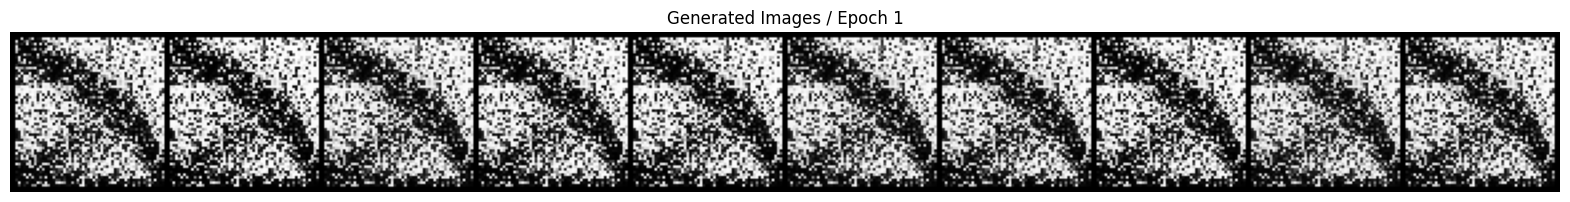

Epoch [10/500] D Loss: 0.6999 G Loss: 0.6564 D(x): 0.5711 D(G(z)): 0.5544
Epoch [20/500] D Loss: 0.6825 G Loss: 0.7120 D(x): 0.5374 D(G(z)): 0.5129
Epoch [30/500] D Loss: 0.6722 G Loss: 0.7288 D(x): 0.5451 D(G(z)): 0.5062
Epoch [40/500] D Loss: 0.6663 G Loss: 0.7141 D(x): 0.5745 D(G(z)): 0.5151
Epoch [50/500] D Loss: 0.6725 G Loss: 0.7261 D(x): 0.5438 D(G(z)): 0.5005


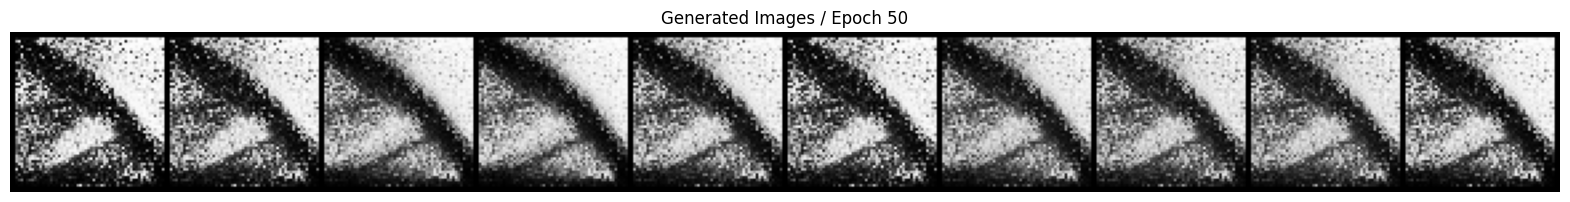

Epoch [60/500] D Loss: 0.7030 G Loss: 0.8013 D(x): 0.5122 D(G(z)): 0.4820
Epoch [70/500] D Loss: 0.6271 G Loss: 0.7880 D(x): 0.5575 D(G(z)): 0.4715
Epoch [80/500] D Loss: 0.6581 G Loss: 0.7713 D(x): 0.5260 D(G(z)): 0.4747
Epoch [90/500] D Loss: 0.6720 G Loss: 0.8229 D(x): 0.5025 D(G(z)): 0.4561
Epoch [100/500] D Loss: 0.6058 G Loss: 0.8835 D(x): 0.6071 D(G(z)): 0.4589


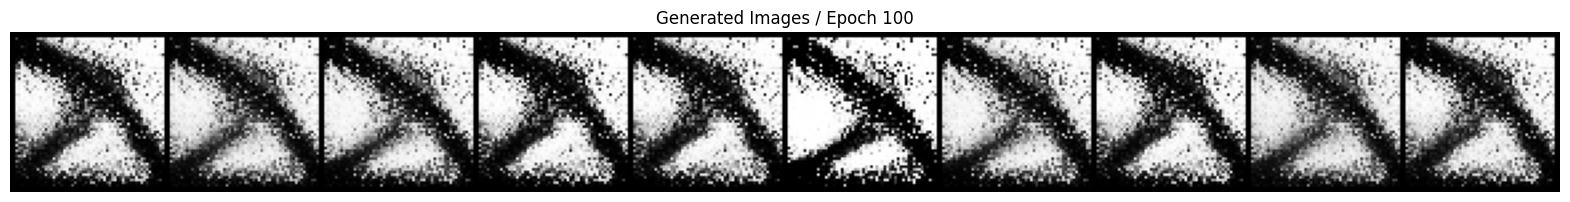

Epoch [110/500] D Loss: 0.6043 G Loss: 0.8466 D(x): 0.5704 D(G(z)): 0.4496
Epoch [120/500] D Loss: 0.5631 G Loss: 0.9864 D(x): 0.6016 D(G(z)): 0.4078
Epoch [130/500] D Loss: 0.6138 G Loss: 0.9330 D(x): 0.5546 D(G(z)): 0.4193
Epoch [140/500] D Loss: 0.6078 G Loss: 0.9250 D(x): 0.5939 D(G(z)): 0.4480
Epoch [150/500] D Loss: 0.6548 G Loss: 0.9969 D(x): 0.5646 D(G(z)): 0.4388


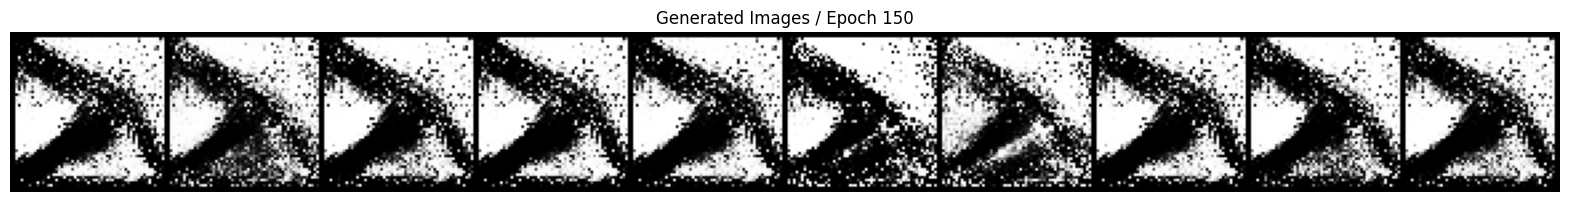

Epoch [160/500] D Loss: 0.6434 G Loss: 0.9531 D(x): 0.5381 D(G(z)): 0.4274
Epoch [170/500] D Loss: 0.5346 G Loss: 0.9896 D(x): 0.6654 D(G(z)): 0.4213
Epoch [180/500] D Loss: 0.4168 G Loss: 1.3976 D(x): 0.7402 D(G(z)): 0.3302
Epoch [190/500] D Loss: 0.2709 G Loss: 2.2260 D(x): 0.8344 D(G(z)): 0.1837
Epoch [200/500] D Loss: 0.4157 G Loss: 1.7205 D(x): 0.7361 D(G(z)): 0.2628


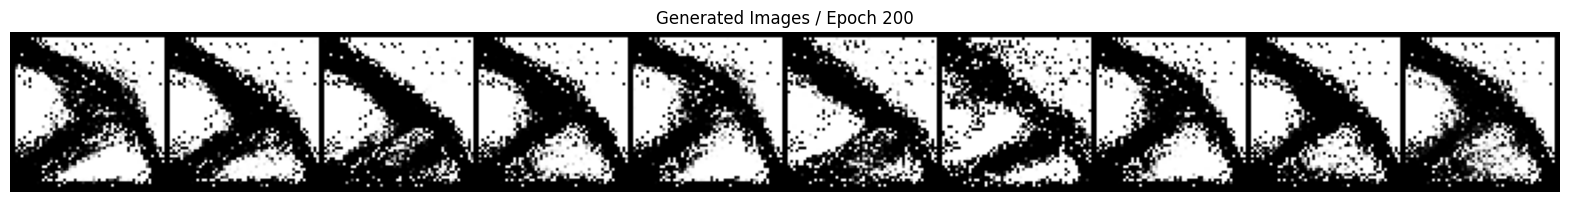

Epoch [210/500] D Loss: 0.5086 G Loss: 1.8569 D(x): 0.7261 D(G(z)): 0.3086
Epoch [220/500] D Loss: 0.3879 G Loss: 1.6935 D(x): 0.7405 D(G(z)): 0.2517
Epoch [230/500] D Loss: 0.3971 G Loss: 1.5349 D(x): 0.7364 D(G(z)): 0.2746
Epoch [240/500] D Loss: 0.4234 G Loss: 1.4992 D(x): 0.7146 D(G(z)): 0.2869
Epoch [250/500] D Loss: 0.4765 G Loss: 1.3243 D(x): 0.6759 D(G(z)): 0.3282


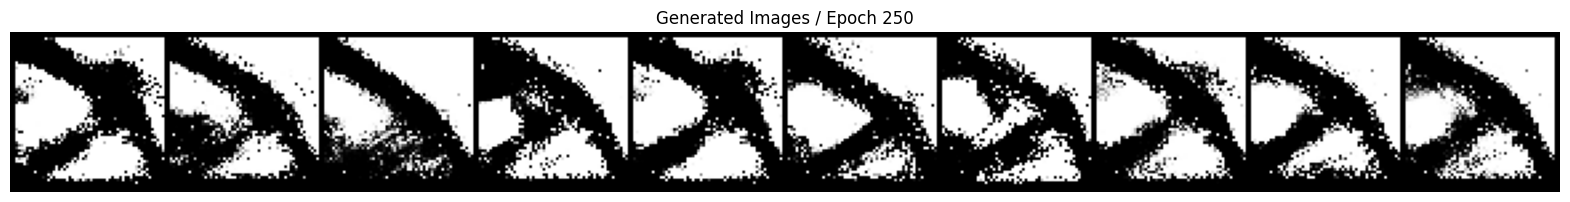

Epoch [260/500] D Loss: 0.4344 G Loss: 1.5308 D(x): 0.7090 D(G(z)): 0.2756
Epoch [270/500] D Loss: 0.4539 G Loss: 1.4575 D(x): 0.6976 D(G(z)): 0.2858
Epoch [280/500] D Loss: 1.0343 G Loss: 1.1310 D(x): 0.4270 D(G(z)): 0.4666
Epoch [290/500] D Loss: 0.6461 G Loss: 0.8577 D(x): 0.5329 D(G(z)): 0.4457
Epoch [300/500] D Loss: 0.5914 G Loss: 0.9797 D(x): 0.5817 D(G(z)): 0.4110


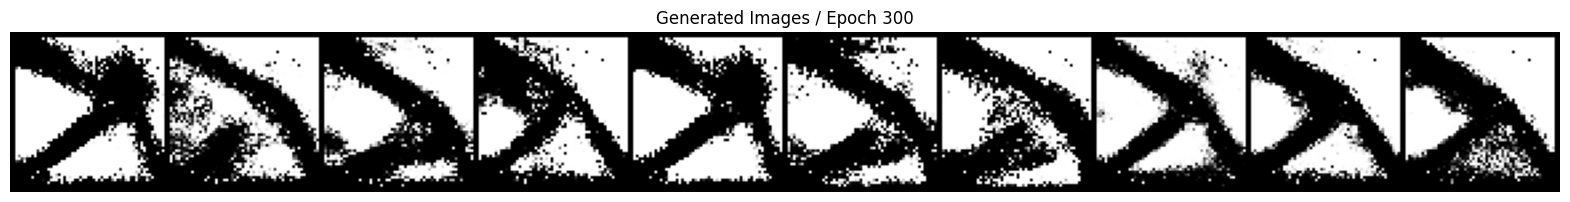

Epoch [310/500] D Loss: 0.5503 G Loss: 1.0690 D(x): 0.6171 D(G(z)): 0.3853
Epoch [320/500] D Loss: 0.4997 G Loss: 1.1789 D(x): 0.6566 D(G(z)): 0.3506
Epoch [330/500] D Loss: 0.4755 G Loss: 1.2774 D(x): 0.6825 D(G(z)): 0.3320
Epoch [340/500] D Loss: 0.6274 G Loss: 0.9512 D(x): 0.5751 D(G(z)): 0.4348
Epoch [350/500] D Loss: 0.5247 G Loss: 1.1604 D(x): 0.6453 D(G(z)): 0.3672


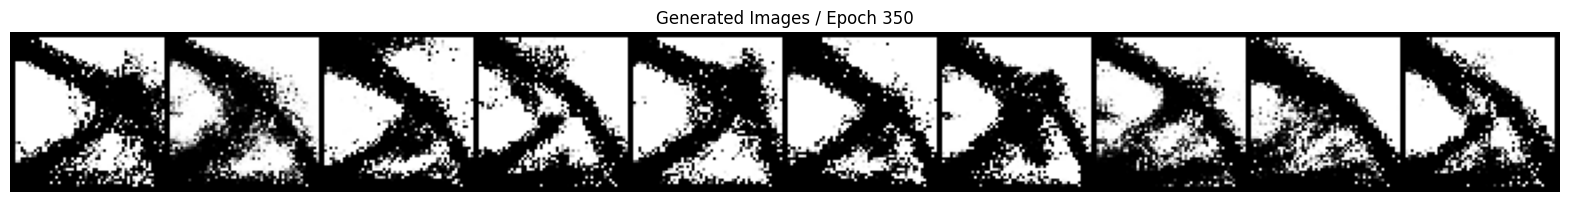

Epoch [360/500] D Loss: 0.5463 G Loss: 1.0452 D(x): 0.6315 D(G(z)): 0.3929
Epoch [370/500] D Loss: 0.4640 G Loss: 1.2929 D(x): 0.6940 D(G(z)): 0.3298
Epoch [380/500] D Loss: 0.4817 G Loss: 1.2508 D(x): 0.6798 D(G(z)): 0.3381
Epoch [390/500] D Loss: 0.5212 G Loss: 1.1844 D(x): 0.6479 D(G(z)): 0.3664
Epoch [400/500] D Loss: 0.4900 G Loss: 1.2603 D(x): 0.6763 D(G(z)): 0.3525


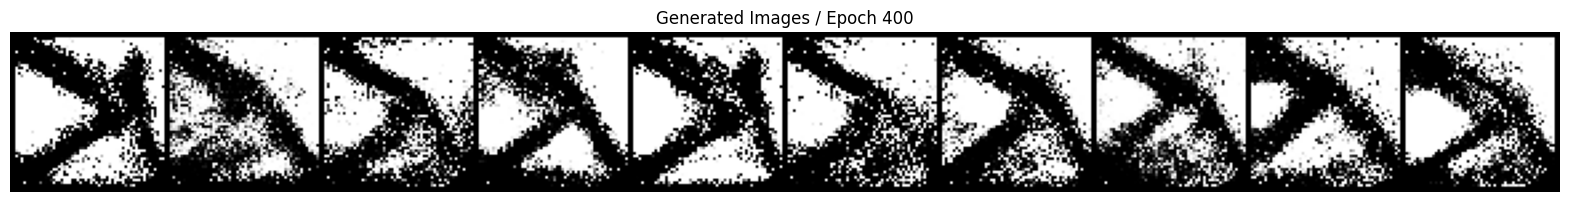

Epoch [410/500] D Loss: 0.4540 G Loss: 1.5061 D(x): 0.7123 D(G(z)): 0.3158
Epoch [420/500] D Loss: 0.4019 G Loss: 1.7899 D(x): 0.7552 D(G(z)): 0.2804
Epoch [430/500] D Loss: 0.3948 G Loss: 1.7939 D(x): 0.7494 D(G(z)): 0.2681
Epoch [440/500] D Loss: 0.3813 G Loss: 1.9324 D(x): 0.7627 D(G(z)): 0.2536
Epoch [450/500] D Loss: 0.3314 G Loss: 2.1117 D(x): 0.7982 D(G(z)): 0.2282


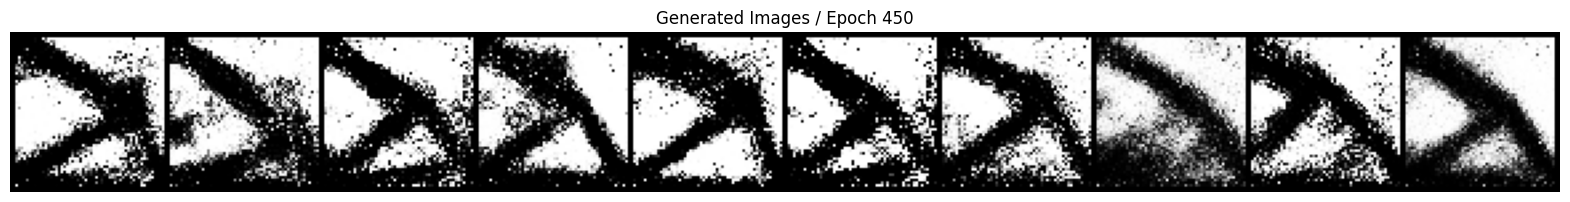

Epoch [460/500] D Loss: 0.3462 G Loss: 2.0130 D(x): 0.7816 D(G(z)): 0.2321
Epoch [470/500] D Loss: 0.3278 G Loss: 2.1362 D(x): 0.7954 D(G(z)): 0.2226
Epoch [480/500] D Loss: 0.3015 G Loss: 2.2091 D(x): 0.8101 D(G(z)): 0.2124
Epoch [490/500] D Loss: 0.3023 G Loss: 2.3700 D(x): 0.8109 D(G(z)): 0.1999
Epoch [500/500] D Loss: 0.2992 G Loss: 2.3205 D(x): 0.8133 D(G(z)): 0.1998


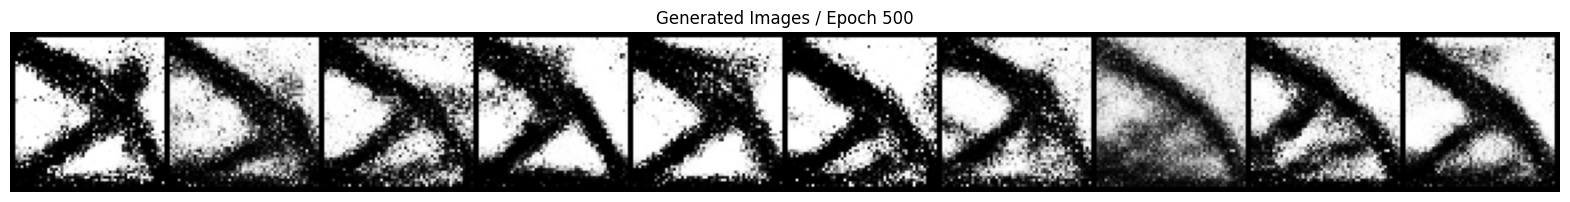

Training Finished
Config: gan_weaker_discriminator
Best Epoch based on G loss: 1
Best G Loss: 0.5768546086549758


In [44]:
import copy
g_loss_history = []
d_loss_history = []
d_real_score_history = []
d_fake_score_history = []

best_g_loss = float("inf")
best_generator_state = None
best_discriminator_state = None
best_epoch = 0

num_epochs = config["epochs"]

for epoch in range(1, num_epochs + 1):

    generator.train()
    discriminator.train()

    total_g_loss = 0.0
    total_d_loss = 0.0
    total_d_real_score = 0.0
    total_d_fake_score = 0.0

    for i, (images,) in enumerate(train_loader):

        images = images.to(device)
        current_batch_size = images.size(0)

        real_images = images.view(current_batch_size, -1)

        real_label = torch.ones(current_batch_size, 1).to(device)
        fake_label = torch.zeros(current_batch_size, 1).to(device)

        # =====================================================
        # 1. Discriminator 학습
        # =====================================================
        for _ in range(config["d_steps"]):

            z = torch.randn(
                current_batch_size,
                config["noise_size"]
            ).to(device)

            fake_images = generator(z)

            d_optimizer.zero_grad()

            real_output = discriminator(real_images)
            fake_output = discriminator(fake_images.detach())

            real_loss = criterion(real_output, real_label)
            fake_loss = criterion(fake_output, fake_label)

            d_loss = (real_loss + fake_loss) / 2

            d_loss.backward()
            d_optimizer.step()

        # =====================================================
        # 2. Generator 학습
        # =====================================================
        for _ in range(config["g_steps"]):

            z = torch.randn(
                current_batch_size,
                config["noise_size"]
            ).to(device)

            fake_images = generator(z)

            g_optimizer.zero_grad()

            fake_output_for_g = discriminator(fake_images)

            # Generator는 fake를 real_label로 속이고 싶음
            g_loss = criterion(fake_output_for_g, real_label)

            g_loss.backward()
            g_optimizer.step()

        total_d_loss += d_loss.item()
        total_g_loss += g_loss.item()
        total_d_real_score += real_output.detach().mean().item()
        total_d_fake_score += fake_output.detach().mean().item()

    avg_d_loss = total_d_loss / len(train_loader)
    avg_g_loss = total_g_loss / len(train_loader)
    avg_d_real_score = total_d_real_score / len(train_loader)
    avg_d_fake_score = total_d_fake_score / len(train_loader)

    d_loss_history.append(avg_d_loss)
    g_loss_history.append(avg_g_loss)
    d_real_score_history.append(avg_d_real_score)
    d_fake_score_history.append(avg_d_fake_score)

    # GAN에서는 best 기준이 애매하지만, 참고용으로 G loss 최저점 저장
    if avg_g_loss < best_g_loss:
        best_g_loss = avg_g_loss
        best_generator_state = copy.deepcopy(generator.state_dict())
        best_discriminator_state = copy.deepcopy(discriminator.state_dict())
        best_epoch = epoch

    if epoch % 10 == 0 or epoch == 1:
        print(
            f"Epoch [{epoch}/{num_epochs}] "
            f"D Loss: {avg_d_loss:.4f} "
            f"G Loss: {avg_g_loss:.4f} "
            f"D(x): {avg_d_real_score:.4f} "
            f"D(G(z)): {avg_d_fake_score:.4f}"
        )

    # =====================================================
    # 3. 주기적으로 이미지 저장 및 출력
    # =====================================================
    if epoch % config["sample_interval"] == 0 or epoch == 1:
        generator.eval()

        with torch.no_grad():
            fake_images = generator(fixed_noise).detach().cpu()
            fake_images = fake_images.view(-1, *config["img_shape"])

        save_path = f"{sample_dir}/GAN_epoch_{epoch}.png"

        save_image(
            fake_images,
            save_path,
            nrow=config["num_fixed_samples"],
            normalize=True
        )

        plt.figure(figsize=(20, 4))
        img = plt.imread(save_path)
        plt.imshow(img)
        plt.title(f"Generated Images / Epoch {epoch}")
        plt.axis("off")
        plt.show()

        generator.train()

print("=" * 60)
print("Training Finished")
print("Config:", config["name"])
print("Best Epoch based on G loss:", best_epoch)
print("Best G Loss:", best_g_loss)

## Loss curve

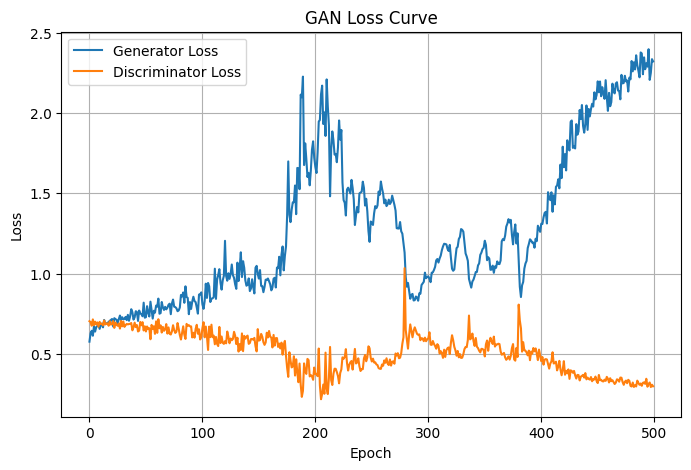

In [45]:
plt.figure(figsize=(8, 5))
plt.plot(g_loss_history, label="Generator Loss")
plt.plot(d_loss_history, label="Discriminator Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GAN Loss Curve")
plt.legend()
plt.grid(True)
plt.show()

## Discriminator Score curve

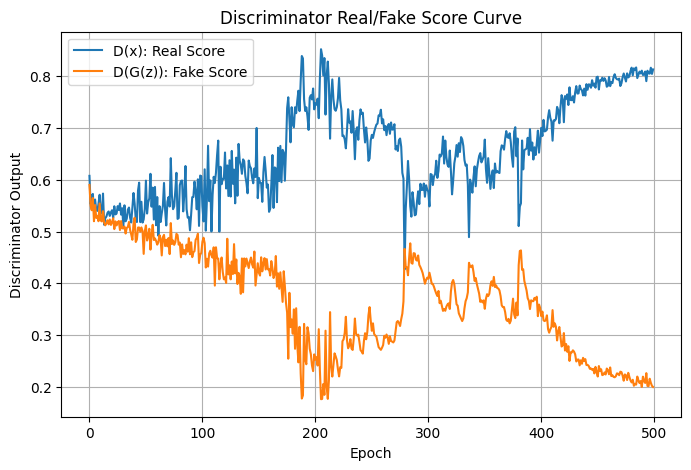

In [46]:
plt.figure(figsize=(8, 5))
plt.plot(d_real_score_history, label="D(x): Real Score")
plt.plot(d_fake_score_history, label="D(G(z)): Fake Score")
plt.xlabel("Epoch")
plt.ylabel("Discriminator Output")
plt.title("Discriminator Real/Fake Score Curve")
plt.legend()
plt.grid(True)
plt.show()

## 최종 이미지 생성

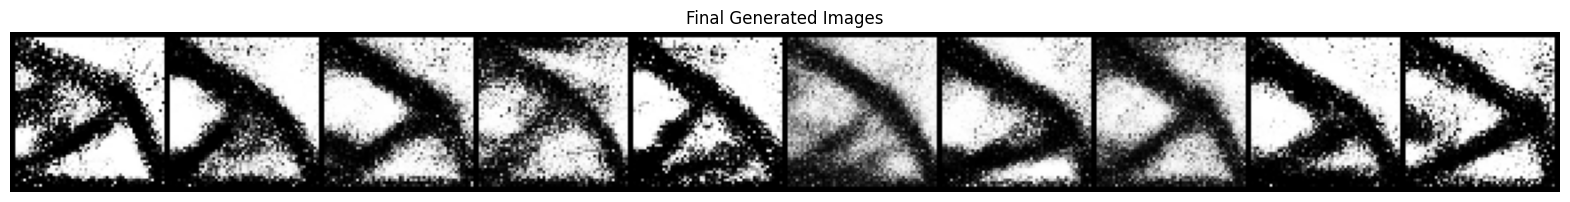

In [47]:
generator.eval()

with torch.no_grad():
    final_noise = torch.randn(
        config["num_fixed_samples"],
        config["noise_size"]
    ).to(device)

    final_fake_images = generator(final_noise).detach().cpu()
    final_fake_images = final_fake_images.view(-1, *config["img_shape"])

save_image(
    final_fake_images,
    f"{sample_dir}/GAN_final.png",
    nrow=config["num_fixed_samples"],
    normalize=True
)

plt.figure(figsize=(20, 4))
img = plt.imread(f"{sample_dir}/GAN_final.png")
plt.imshow(img)
plt.title("Final Generated Images")
plt.axis("off")
plt.show()

## Best G Loss 기준 모델 복원해서 보기

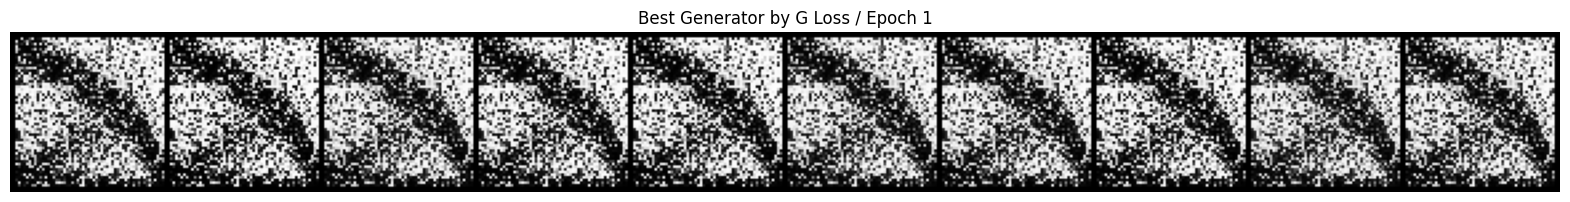

In [48]:
best_generator = Generator(
    noise_size=config["noise_size"],
    img_size=config["img_size"],
    hidden_dims=config["g_hidden_dims"],
    dropout_rate=config["g_dropout"]
).to(device)

best_generator.load_state_dict(best_generator_state)
best_generator.eval()

with torch.no_grad():
    best_fake_images = best_generator(fixed_noise).detach().cpu()
    best_fake_images = best_fake_images.view(-1, *config["img_shape"])

save_image(
    best_fake_images,
    f"{sample_dir}/GAN_best_g_loss.png",
    nrow=config["num_fixed_samples"],
    normalize=True
)

plt.figure(figsize=(20, 4))
img = plt.imread(f"{sample_dir}/GAN_best_g_loss.png")
plt.imshow(img)
plt.title(f"Best Generator by G Loss / Epoch {best_epoch}")
plt.axis("off")
plt.show()